In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('data/train.csv')

# Look at the first 5 rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
# Select only the columns we need
data = df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']]

# Check for missing values
print(data.isnull().sum())

# Basic statistics
data.describe()

GrLivArea       0
BedroomAbvGr    0
FullBath        0
SalePrice       0
dtype: int64


,GrLivArea,BedroomAbvGr,FullBath,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000
mean,1515.463699,2.866438,1.565068,180921.195890
std,525.480383,0.815778,0.550916,79442.502883
min,334.000000,0.000000,0.000000,34900.000000
25%,1129.500000,2.000000,1.000000,129975.000000
50%,1464.000000,3.000000,2.000000,163000.000000
75%,1776.750000,3.000000,2.000000,214000.000000
max,5642.000000,8.000000,3.000000,755000.000000


In [3]:
from sklearn.model_selection import train_test_split

# X = the inputs (features), y = what we want to predict
X = data[['GrLivArea', 'BedroomAbvGr', 'FullBath']]
y = data['SalePrice']

# Split into training data (80%) and testing data (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1168
Testing samples: 292


In [4]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train it on our training data
model.fit(X_train, y_train)

# See what the model learned
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [   104.02630701 -26655.16535734  30014.32410896]
Intercept: 52261.748626944594


In [5]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Predict prices for the test set (data the model has never seen)
y_pred = model.predict(X_test)

# Evaluate accuracy
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 52975.71771338122
R² Score: 0.6341189942328371


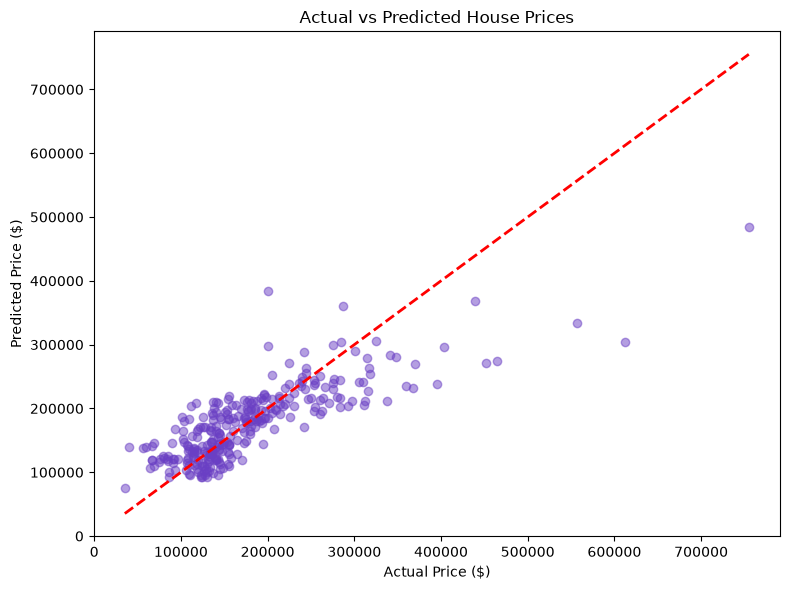

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='#6a3fc4')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted House Prices')
plt.tight_layout()
plt.savefig('prediction_plot.png')
plt.show()

## Summary

This project implements a **Linear Regression** model to predict house prices 
based on square footage (GrLivArea), number of bedrooms, and number of bathrooms, 
using the Kaggle House Prices dataset.

**Results:**
- RMSE: ~$52,976
- R² Score: 0.634

The model explains ~63% of price variation using just 3 features, demonstrating 
a solid baseline for price prediction. Future improvements could include 
additional features (location, house condition, garage, etc.) for higher accuracy.